In [23]:
%%capture
!pip install koreanize-matplotlib
import koreanize_matplotlib

In [24]:
%%capture
!pip install catboost

In [30]:
import pandas as pd
df = pd.read_csv('/content/exchange_add_debt.csv')

In [99]:
# 인플레이션율 계산 (전년 동월 대비)
df["한국 인플레이션율"] = df["한국 소비자 물가지수"].pct_change(periods=12) * 100
df["미국 인플레이션율"] = df["미국 소비자 물가지수"].pct_change(periods=12) * 100

# 인플레이션 격차 계산 (한국 - 미국)
df["인플레이션 격차"] = df["한국 인플레이션율"] - df["미국 인플레이션율"]

# 실질 GDP 계산
df["실질GDP"] = df["한국 GDP"] / df["한국 GDP 디플레이터"] * 100

# 실질 GDP 성장률 계산 (전년 동기 대비)
df["실질GDP성장률"] = df["실질GDP"].pct_change(periods=12) * 100

<ipython-input-99-8ffb3afc5d8f>:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["실질GDP성장률"] = df["실질GDP"].pct_change(periods=12) * 100


In [98]:
features = [ '경제 심리 지수',
            '한국 기준 금리',
            '미국 기준 금리',
            '한국 외환 보유액',
            '한국 실업률',
            '한국 주가지수',
            '미국 주가지수',
            'WTI 유가',
            '두바이 유가',
            'Brent 유가',
            '천연가스 가격',
            '유연탄 가격',
            '철광석 가격',
            '구리 가격',
            '알루미늄 가격',
            '니켈 가격',
            '아연 가격',
            '금 가격',
            '대두 가격',
            '옥수수 가격',
            '소맥 가격',
            '원당 가격',
            '원면 가격',
            '외국인 투자 금액',
            '한국 상품수지',
            '한국 경상수지',
            '한국 인플레이션율',
            '미국 인플레이션율',
            '인플레이션 격차',
            '실질GDP',
            '실질GDP성장률',
            '한국 10년 채권수익률',
            '미국 10년 채권수익률',
             ]

target=['원/달러환율']

In [100]:
# 날짜 컬럼 처리 (필요 시)
df['TIME'] = pd.to_datetime(df['TIME'])  # TIME 컬럼 존재 시

# 결측치 제거 (전체 피처 기준으로)
df_ml = df[features + target].dropna()

In [101]:
from sklearn.model_selection import train_test_split

X = df_ml[features]
y = df_ml['원/달러환율']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [32]:
df.columns

Index(['TIME', '원/달러환율', '한국 장기 시장 금리', '미국 장기 시장 금리', '중국 장기 시장 금리',
       '한국 단기 시장 금리', '미국 단기 시장 금리', '중국 단기 시장 금리', '전체 수출 총액', '미국 수출 총액',
       '중국 수출 총액', '전체 수입 총액', '미국 수입 총액', '중국 수입 총액', '소득 교역 조건 지수',
       '해외 직접 투자 금액', '경제 심리 지수', '한국 기준 금리', '미국 기준 금리', '중국 기준 금리',
       '한국 소비자 물가지수', '미국 소비자 물가지수', '중국 소비자 물가지수', '한국 외환 보유액', '미국 외환 보유액',
       '중국 외환 보유액', '한국 산업 생산 지수', '미국 산업 생산 지수', '한국 실업률', '미국 실업률',
       '한국 주가지수', '미국 주가지수', '중국 주가지수', 'WTI 유가', '두바이 유가', 'Brent 유가',
       '천연가스 가격', '유연탄 가격', '철광석 가격', '구리 가격', '알루미늄 가격', '니켈 가격', '아연 가격',
       '금 가격', '대두 가격', '옥수수 가격', '소맥 가격', '원당 가격', '원면 가격', '외국인 투자 금액',
       '한국 경상수지', '미국 경상수지', '중국 경상수지', '한국 상품수지', '미국 상품수지', '중국 상품수지',
       '한국 경제성장률', '미국 경제성장률', '중국 경제성장률', '한국 GDP', '미국 GDP', '중국 GDP',
       '한국 GDP 디플레이터', '한국 중앙정부 부채 비율', '미국 중앙정부 부채 비율', '한국 10년 채권수익률',
       '미국 10년 채권수익률', '한국 인플레이션율', '미국 인플레이션율', '인플레이션 격차', '실질GDP',
       '실질GDP성장률'],
      dtype='object')

In [50]:
# 라이브러리 임포트
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# 5. 모델별 성능 비교
results = {}

# LightGBM
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
results['LightGBM'] = {
    'MSE': mean_squared_error(y_test, y_pred_lgbm),
    'R²': r2_score(y_test, y_pred_lgbm)
}

# XGBoost
xgb = XGBRegressor(random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'R²': r2_score(y_test, y_pred_xgb)
}

# CatBoost
cat = CatBoostRegressor(verbose=0, random_state=42)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)
results['CatBoost'] = {
    'MSE': mean_squared_error(y_test, y_pred_cat),
    'R²': r2_score(y_test, y_pred_cat)
}

# 결과 정리 출력
results_df = pd.DataFrame(results).T
print(results_df)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1886
[LightGBM] [Info] Number of data points in the train set: 183, number of used features: 33
[LightGBM] [Info] Start training from score 1102.506833
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

# 변수추가

In [36]:
df['금리차'] = df['한국 기준 금리'] - df['미국 기준 금리']
df['주가지수 비율'] = df['한국 주가지수'] / df['미국 주가지수']
df['외환보유액_변화'] = df['한국 외환 보유액'].diff()

In [43]:
features = [ '경제 심리 지수',
            '한국 기준 금리',
            '미국 기준 금리',
            '한국 외환 보유액',
            '한국 실업률',
            '한국 주가지수',
            '미국 주가지수',
            'WTI 유가',
            '두바이 유가',
            'Brent 유가',
            '천연가스 가격',
            '유연탄 가격',
            '철광석 가격',
            '구리 가격',
            '알루미늄 가격',
            '니켈 가격',
            '아연 가격',
            '금 가격',
            '대두 가격',
            '옥수수 가격',
            '소맥 가격',
            '원당 가격',
            '원면 가격',
            '외국인 투자 금액',
            '한국 상품수지',
            '한국 경상수지',
            '한국 인플레이션율',
            '미국 인플레이션율',
            '인플레이션 격차',
            '실질GDP',
            '실질GDP성장률',
            '한국 10년 채권수익률',
            '미국 10년 채권수익률',
             '금리차',
             '주가지수 비율',
             '외환보유액_변화'
             ]

target=['원/달러환율']

In [44]:
# 날짜 컬럼 처리 (필요 시)
df['TIME'] = pd.to_datetime(df['TIME'])  # TIME 컬럼 존재 시

# 결측치 제거 (전체 피처 기준으로)
df_ml = df[features + target].dropna()

In [45]:
from sklearn.model_selection import train_test_split

X = df_ml[features]
y = df_ml['원/달러환율']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [46]:
# 라이브러리 임포트
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# 5. 모델별 성능 비교
results = {}

# LightGBM
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
results['LightGBM'] = {
    'MSE': mean_squared_error(y_test, y_pred_lgbm),
    'R²': r2_score(y_test, y_pred_lgbm)
}

# XGBoost
xgb = XGBRegressor(random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'R²': r2_score(y_test, y_pred_xgb)
}

# CatBoost
cat = CatBoostRegressor(verbose=0, random_state=42)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)
results['CatBoost'] = {
    'MSE': mean_squared_error(y_test, y_pred_cat),
    'R²': r2_score(y_test, y_pred_cat)
}

# 결과 정리 출력
results_df = pd.DataFrame(results).T
print(results_df)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2025
[LightGBM] [Info] Number of data points in the train set: 182, number of used features: 36
[LightGBM] [Info] Start training from score 1102.860551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# 변수 선택 (라쏘)

덜 중요한 변수 → 계수 0으로 만들기

In [51]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split

# feature와 target 정의 (원/달러환율 제외한 피처 리스트)
features = [ '경제 심리 지수', '한국 기준 금리', '미국 기준 금리', '한국 외환 보유액',
             '한국 실업률', '한국 주가지수', '미국 주가지수', 'WTI 유가', '두바이 유가',
             'Brent 유가', '천연가스 가격', '유연탄 가격', '철광석 가격', '구리 가격',
             '알루미늄 가격', '니켈 가격', '아연 가격', '금 가격', '대두 가격', '옥수수 가격',
             '소맥 가격', '원당 가격', '원면 가격', '외국인 투자 금액', '한국 상품수지',
             '한국 경상수지', '한국 인플레이션율', '미국 인플레이션율', '인플레이션 격차',
             '실질GDP', '실질GDP성장률', '한국 10년 채권수익률', '미국 10년 채권수익률' ]

# 타겟
target = ['원/달러환율']

# 피처 + 타겟 결측치 제거
df_ml = df[features + target].dropna()
X = df_ml[features]
y = df_ml['원/달러환율']

# 훈련/테스트 분리 (시계열 보존 위해 shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Lasso 모델 학습 및 변수 선택
lasso = LassoCV(cv=5).fit(X_train, y_train)
model = SelectFromModel(lasso, prefit=True)
selected_features = X_train.columns[model.get_support()]

# 결과 출력
print("✅ 선택된 변수 목록:")
print(selected_features.tolist())


✅ 선택된 변수 목록:
['한국 외환 보유액', '니켈 가격', '실질GDP']


-> 너무 적음

## 랜덤 포레스트 상위 변수 10개만 추출

In [52]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 중요도 상위 10개 변수 선택
importance_df = pd.DataFrame({
    '변수명': X_train.columns,
    '중요도': model.feature_importances_
}).sort_values(by='중요도', ascending=False)

top_features = importance_df.head(10)['변수명'].tolist()


In [53]:
top_features

['미국 기준 금리',
 '미국 주가지수',
 '미국 10년 채권수익률',
 '천연가스 가격',
 '실질GDP',
 '소맥 가격',
 '인플레이션 격차',
 '아연 가격',
 '한국 외환 보유액',
 '철광석 가격']

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 183, number of used features: 10
[LightGBM] [Info] Start training from score 1102.506833
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

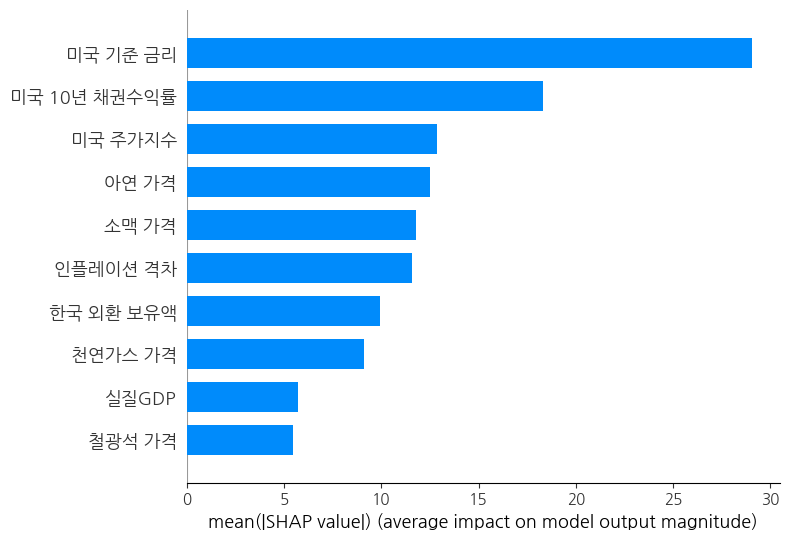

In [54]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 선택된 변수 리스트 (예: Random Forest 기반 상위 10개)
selected_features = ['미국 기준 금리', '미국 주가지수', '미국 10년 채권수익률', '천연가스 가격',
                     '실질GDP', '소맥 가격', '인플레이션 격차', '아연 가격',
                     '한국 외환 보유액', '철광석 가격']

X = df_ml[selected_features]
y = df_ml['원/달러환율']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 모델 학습
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# SHAP 값 계산
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

# 요약 그래프 (전체 변수 영향력 시각화)
shap.summary_plot(shap_values, X_train, plot_type="bar")


- 세개의 분석에 의해 선별된 변수들로 머신러닝

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# 주요 피처
selected_features = [
    '미국 기준 금리',
    '미국 주가지수',
    '미국 10년 채권수익률',
    '천연가스 가격',
    '실질GDP',
    '소맥 가격',
    '인플레이션 격차',
    '아연 가격',
    '한국 외환 보유액',
    '철광석 가격',
    '니켈 가격'
]

# 타겟 변수
target = '원/달러환율'

# 전처리 (결측치 제거)
df_ml = df[selected_features + [target]].dropna()

# 분할
X = df_ml[selected_features]
y = df_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 모델 학습 및 평가
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 성능 출력
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"✅ LGBM Regressor 결과\nMSE: {mse:.4f}\nR² Score: {r2:.4f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 183, number of used features: 11
[LightGBM] [Info] Start training from score 1102.506833
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

-> 오히려 나빠짐

## LSTM(시계열 특화 모델)

In [102]:
%%capture
!pip install tensorflow

In [103]:
from sklearn.preprocessing import MinMaxScaler

# features와 target 구성
features = [ '경제 심리 지수',
            '한국 기준 금리',
            '미국 기준 금리',
            '한국 외환 보유액',
            '한국 실업률',
            '한국 주가지수',
            '미국 주가지수',
            'WTI 유가',
            '두바이 유가',
            'Brent 유가',
            '천연가스 가격',
            '유연탄 가격',
            '철광석 가격',
            '구리 가격',
            '알루미늄 가격',
            '니켈 가격',
            '아연 가격',
            '금 가격',
            '대두 가격',
            '옥수수 가격',
            '소맥 가격',
            '원당 가격',
            '원면 가격',
            '외국인 투자 금액',
            '한국 상품수지',
            '한국 경상수지',
            '한국 인플레이션율',
            '미국 인플레이션율',
            '인플레이션 격차',
            '실질GDP',
            '실질GDP성장률',
            '한국 10년 채권수익률',
            '미국 10년 채권수익률',
             ]
target = ['원/달러환율']

# 결측치 제거
df_ml = df[features + target].dropna()

# 정규화
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_ml)

X_scaled = scaled[:, :-1] # 독립변수(피처)
y_scaled = scaled[:, -1] # 종속변수(환율)

 ##### 아래 코드 설명

 - LSTM은 이전 시간대의 데이터를 바탕으로 미래를 예측합니다. 그래서 연속된 데이터(시퀀스)를 만들어줘야 합니다.

- sequence_length = 12이면, 12개월 데이터를 기반으로 13번째 달의 환율을 예측합니다.

- X_seq: (샘플 수, 12, 피처 수) 형태의 입력 데이터

- y_seq: 각 시퀀스에 대한 예측 목표 값 (환율)

In [113]:
import numpy as np

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

sequence_length = 12
X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)


In [114]:
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),  # 과적합 방지
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),  # 마지막 LSTM은 return_sequences=False (default)
    Dense(1)   # 예측할 환율 1개 출력
])

model.compile(loss='mse', optimizer='adam')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.0718 - val_loss: 0.0501
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0285 - val_loss: 0.0265
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0198 - val_loss: 0.0229
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0101 - val_loss: 0.0201
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0081 - val_loss: 0.0305
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0061 - val_loss: 0.0318
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0069 - val_loss: 0.0279
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0053 - val_loss: 0.0242
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0050 - val_loss: 0.0314
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0052 - val_loss: 0.0455
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0050 - val_loss: 0.0330
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0

In [116]:
y_pred_scaled = model.predict(X_test)

# 타겟값만 역변환하기 위해 0으로 채운 후 마지막 컬럼만 추출
y_pred = scaler.inverse_transform(np.hstack([np.zeros((len(y_pred_scaled), X_scaled.shape[1])), y_pred_scaled]))[:, -1]
y_true = scaler.inverse_transform(np.hstack([np.zeros((len(y_test), X_scaled.shape[1])), y_test.reshape(-1, 1)]))[:, -1]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step


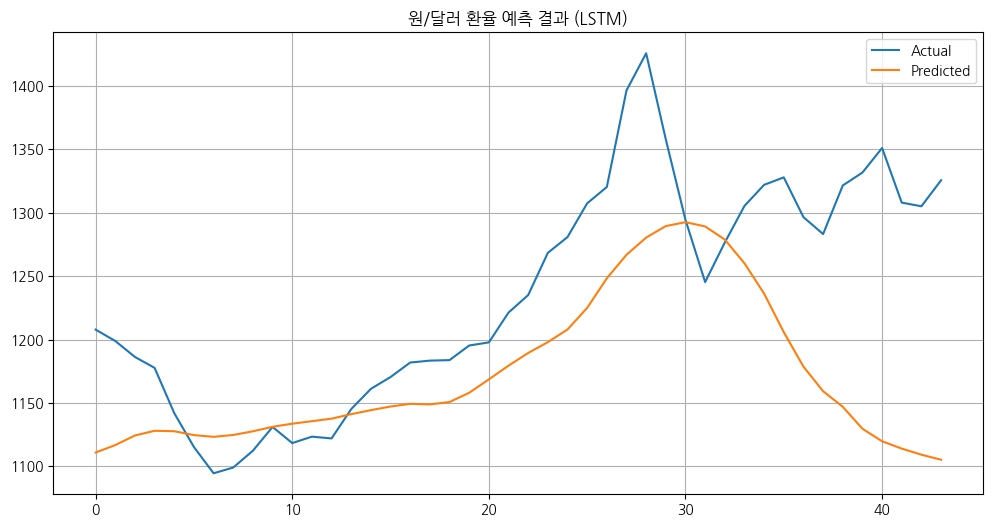

✅ LSTM 결과
MSE: 9211.0959
R²: -0.2012


In [68]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("원/달러 환율 예측 결과 (LSTM)")
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ LSTM 결과\nMSE: {mse:.4f}\nR²: {r2:.4f}")


#### 모델 튜닝

In [119]:
y_pred_scaled = model.predict(X_test)

# 타겟값만 역변환하기 위해 0으로 채운 후 마지막 컬럼만 추출
y_pred = scaler.inverse_transform(np.hstack([np.zeros((len(y_pred_scaled), X_scaled.shape[1])), y_pred_scaled]))[:, -1]
y_true = scaler.inverse_transform(np.hstack([np.zeros((len(y_test), X_scaled.shape[1])), y_test.reshape(-1, 1)]))[:, -1]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step


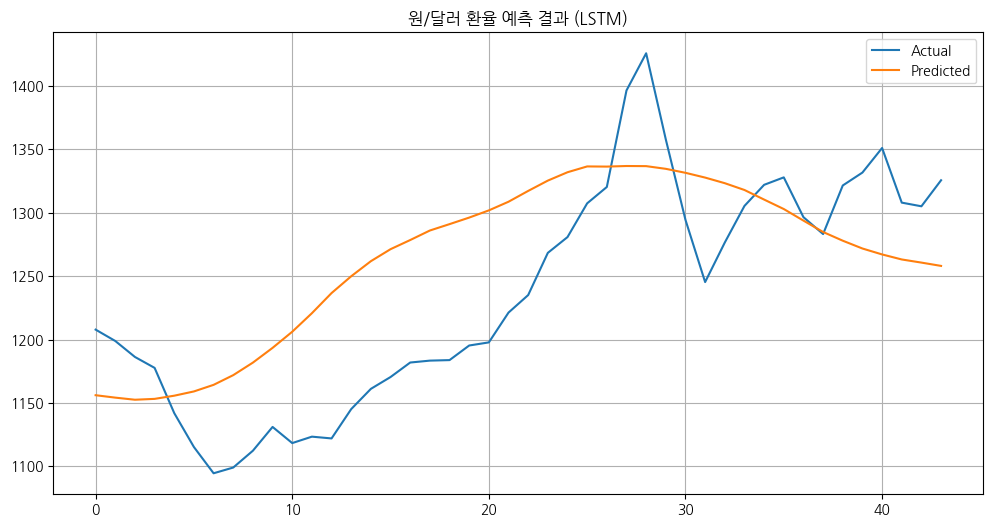

✅ LSTM 결과
MSE: 4710.1570
R²: 0.3857


In [74]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("원/달러 환율 예측 결과 (LSTM)")
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ LSTM 결과\nMSE: {mse:.4f}\nR²: {r2:.4f}")


두번째시도

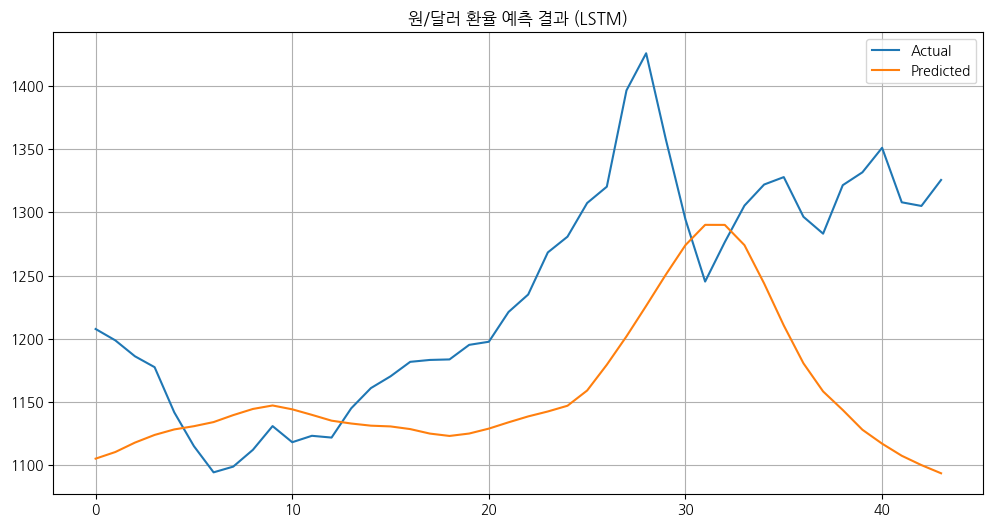

✅ LSTM 결과
MSE: 12538.5048
R²: -0.6351


In [120]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("원/달러 환율 예측 결과 (LSTM)")
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ LSTM 결과\nMSE: {mse:.4f}\nR²: {r2:.4f}")

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 89.79
RMSE: 111.98


#### 모델 튜닝 version2

단기 패턴은 Conv1D, 장기 트렌드는 LSTM

In [82]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. 시퀀스 생성 함수
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

# 3. 스케일링
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))


# 4. 시퀀스 데이터 생성
sequence_length = 12
X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)

# 5. 학습/테스트 분리
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.1),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(loss='mse', optimizer=Adam(learning_rate=0.0005))

# 7. 학습
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop], verbose=1)

# 8. 예측 및 평가
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# 9. 결과 출력
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"✅ Conv1D + LSTM 결과\nMSE: {mse:.4f}\nR²: {r2:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.1589 - val_loss: 0.1597
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0920 - val_loss: 0.0361
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0430 - val_loss: 0.0047
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0373 - val_loss: 0.0289
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0342 - val_loss: 0.0182
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0252 - val_loss: 0.0175
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0186 - val_loss: 0.0303
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0184 - val_loss: 0.0290
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0224 - val_loss: 0.0436
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0198 - val_loss: 0.0469
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136 - val_loss: 0.0289
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

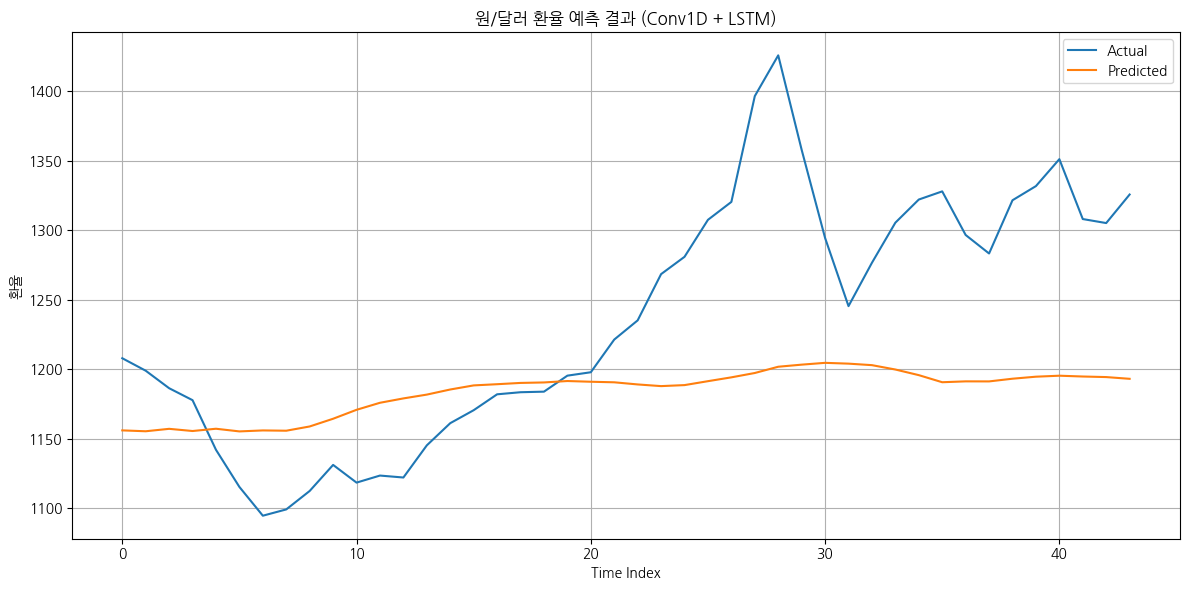

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual')      # 실제 환율
plt.plot(y_pred, label='Predicted')   # 예측 환율
plt.title('원/달러 환율 예측 결과 (Conv1D + LSTM)')
plt.xlabel('Time Index')
plt.ylabel('환율')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 2025년 1월 예측

In [95]:
features = [
    '경제 심리 지수', '한국 기준 금리', '미국 기준 금리', '한국 외환 보유액', '한국 실업률',
    '한국 주가지수', '미국 주가지수', 'WTI 유가', '두바이 유가', 'Brent 유가',
    '천연가스 가격', '유연탄 가격', '철광석 가격', '구리 가격', '알루미늄 가격',
    '니켈 가격', '아연 가격', '금 가격', '대두 가격', '옥수수 가격',
    '소맥 가격', '원당 가격', '원면 가격', '외국인 투자 금액', '한국 상품수지',
    '한국 경상수지', '한국 인플레이션율', '미국 인플레이션율', '인플레이션 격차',
    '실질GDP', '실질GDP성장률', '한국 10년 채권수익률', '미국 10년 채권수익률'
]


In [96]:
# 최근 12개월 데이터 추출
latest_data = df_ml[features].iloc[-12:]
latest_data = latest_data[scaler_X.feature_names_in_]

# 스케일링 및 시퀀스 변환
X_latest_scaled = scaler_X.transform(latest_data)  # shape: (12, 33)
X_latest_seq = X_latest_scaled.reshape(1, 12, len(features))  # shape: (1, 12, 33)

# 예측
y_future_scaled = model.predict(X_latest_seq)
y_future = scaler_y.inverse_transform(y_future_scaled)

print(f"📈 예측된 2025년 1월 원/달러 환율: {y_future[0][0]:.2f} 원")


ValueError: cannot reshape array of size 132 into shape (1,12,33)

In [88]:
# 12개월치 시퀀스를 가져오자 (행이 12개여야 함!)
latest_data = df_ml[features].iloc[-12:].copy()

# 피처 순서 보정
latest_data = latest_data[scaler_X.feature_names_in_]

# 스케일링 및 reshape
X_latest_scaled = scaler_X.transform(latest_data)  # shape: (12, 33)
X_latest_seq = X_latest_scaled.reshape(1, 12, len(features))  # shape: (1, 12, 33)

print(latest_data.shape)


ValueError: cannot reshape array of size 132 into shape (1,12,33)

In [89]:
print(df_ml.shape)


(229, 34)


In [90]:
latest_data = df_ml[features].iloc[-12:]
print(latest_data.shape)


(12, 33)


In [91]:
print(type(X_latest_scaled))  # numpy.ndarray인지 확인
print(X_latest_scaled.shape)  # (12, 33) 나와야 함


<class 'numpy.ndarray'>
(12, 11)


In [ ]:
print(len(features))  # 33인지 확인
